# 1. Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./datasets/synthetic_heart_disease_dataset.csv')
print(df.shape)
print('\n\n', df.info())
print("\n\n", df.isnull().sum())

(50000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int

In [2]:
df.head(10)

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,0,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,1,1,0,0,0,164,67,108,116,220,1
5,50,Male,116,186,25.3,Current,NaN,Sedentary,Average,Medium,0,0,1,0,0,171,91,106,97,225,0
6,67,Male,93,158,22.3,Never,Moderate,Moderate,Unhealthy,Low,1,0,0,0,0,153,82,85,145,156,1
7,51,Male,75,176,18.2,Former,NaN,Active,Average,Medium,0,0,0,1,0,117,63,89,143,154,0
8,54,Male,105,189,19.6,Current,NaN,Moderate,Healthy,High,0,0,1,0,0,164,97,75,147,267,0
9,74,Male,106,197,35.7,Current,Low,Moderate,Unhealthy,Low,0,0,0,0,0,114,69,87,117,195,0


In [11]:
if 'Alcohol_Intake' in df.columns:
    df = df.drop('Alcohol_Intake', axis=1)
    print("Column Deleted successfully")
else:
    print("Column doesn't exists")

Column doesn't exists


In [10]:
df.columns = df.columns.str.lower()
df.head(10)

,age,gender,weight,height,bmi,smoking,physical_activity,diet,stress_level,hypertension,diabetes,hyperlipidemia,family_history,previous_heart_attack,systolic_bp,diastolic_bp,heart_rate,blood_sugar_fasting,cholesterol_total,heart_disease
0,48,Male,78,157,26.4,Never,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Average,Low,0,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,Sedentary,Healthy,Low,1,1,0,0,0,164,67,108,116,220,1
5,50,Male,116,186,25.3,Current,Sedentary,Average,Medium,0,0,1,0,0,171,91,106,97,225,0
6,67,Male,93,158,22.3,Never,Moderate,Unhealthy,Low,1,0,0,0,0,153,82,85,145,156,1
7,51,Male,75,176,18.2,Former,Active,Average,Medium,0,0,0,1,0,117,63,89,143,154,0
8,54,Male,105,189,19.6,Current,Moderate,Healthy,High,0,0,1,0,0,164,97,75,147,267,0
9,74,Male,106,197,35.7,Current,Moderate,Unhealthy,Low,0,0,0,0,0,114,69,87,117,195,0


# 2. Exploratory Data Analysis

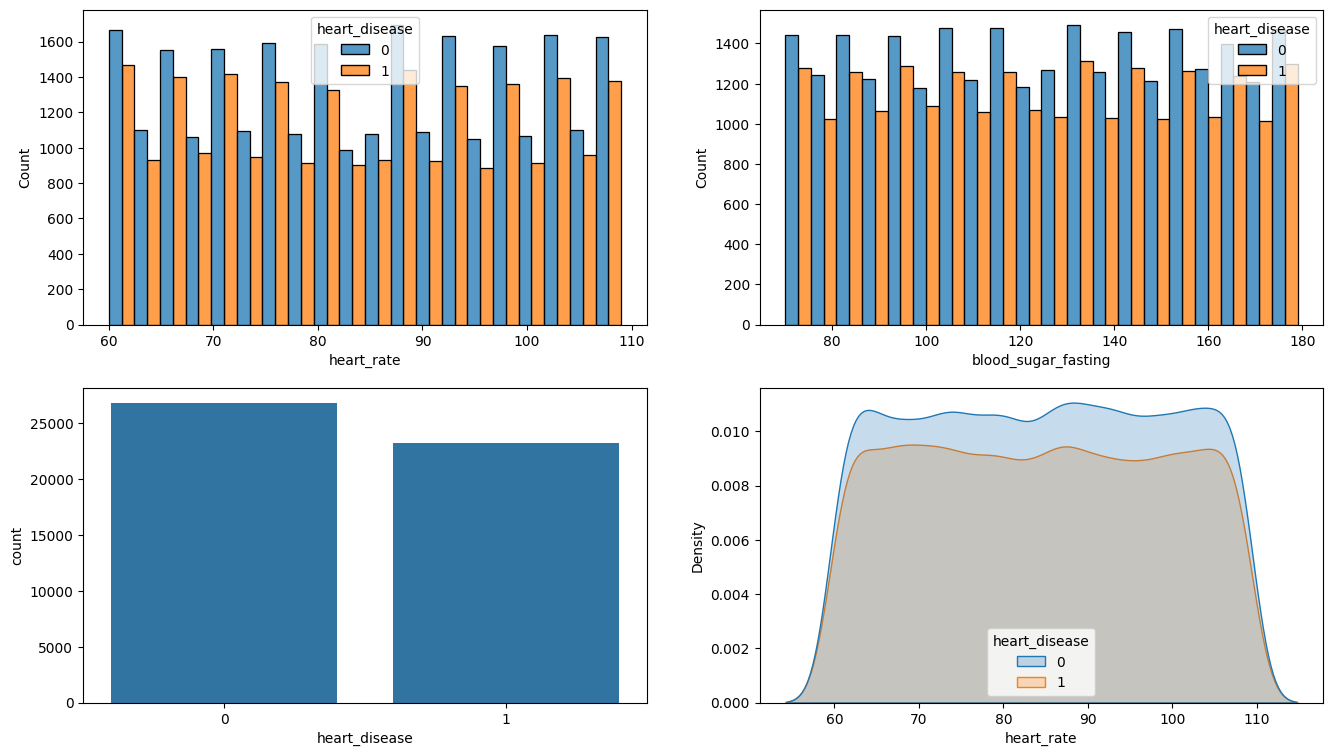

In [36]:
plt.figure(figsize=(16,9))
plt.subplot(2,2,1)
sns.histplot(data=df, x='heart_rate',hue= 'heart_disease',multiple='dodge', bins=20)
plt.subplot(2,2,2)
sns.histplot(data=df, x='blood_sugar_fasting', hue='heart_disease', multiple='dodge', bins=20)
plt.subplot(2,2,3)
sns.countplot(data=df, x='heart_disease')
plt.subplot(2,2,4)
sns.kdeplot(data=df, x='heart_rate', hue='heart_disease', fill=True)
plt.show()

# 3. Model Training

In [55]:
from sklearn. model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
df.head(10)

,age,gender,weight,height,bmi,smoking,physical_activity,diet,stress_level,hypertension,diabetes,hyperlipidemia,family_history,previous_heart_attack,systolic_bp,diastolic_bp,heart_rate,blood_sugar_fasting,cholesterol_total,heart_disease
0,48,Male,78,157,26.4,Never,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Average,Low,0,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,Sedentary,Healthy,Low,1,1,0,0,0,164,67,108,116,220,1
5,50,Male,116,186,25.3,Current,Sedentary,Average,Medium,0,0,1,0,0,171,91,106,97,225,0
6,67,Male,93,158,22.3,Never,Moderate,Unhealthy,Low,1,0,0,0,0,153,82,85,145,156,1
7,51,Male,75,176,18.2,Former,Active,Average,Medium,0,0,0,1,0,117,63,89,143,154,0
8,54,Male,105,189,19.6,Current,Moderate,Healthy,High,0,0,1,0,0,164,97,75,147,267,0
9,74,Male,106,197,35.7,Current,Moderate,Unhealthy,Low,0,0,0,0,0,114,69,87,117,195,0


In [50]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

cat_col = ['gender', 'smoking', 'physical_activity', 'diet', 'stress_level']
num_col = ['age', 'weight', 'height', 'bmi', 'hypertension', 'diabetes', 'hyperlipidemia', 'family_history', 'previous_heart_attack', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'blood_sugar_fasting', 'cholesterol_total']

processing = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col),
        ('num', StandardScaler(), num_col)
    ]
)

knn = KNeighborsClassifier(n_neighbors=7)
lr = LogisticRegression(random_state=42, max_iter=1000)
cart = DecisionTreeClassifier(criterion='gini', random_state=42)
rf = RandomForestClassifier(random_state=42, n_estimators=150)

sc = StackingClassifier(
    estimators=[
        ('knn', knn),
        ('Logistic_Regression', lr),
        ('Decision_Tree_CART', cart),
    ],
    final_estimator=rf,
    cv=6,
    n_jobs=-1
)

pipeline = Pipeline([
    ('processing', processing),
    ('model', sc)
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('processing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

The accuracy is: 100.00%


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



<Axes: >

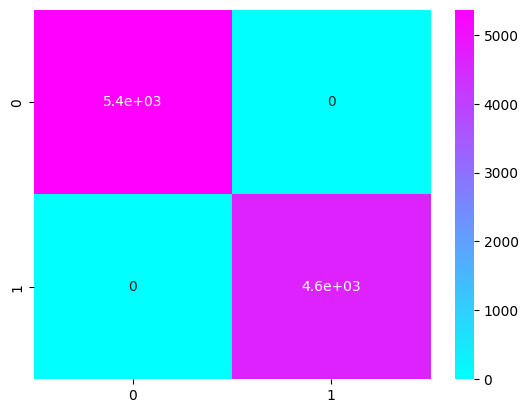

In [54]:
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"The accuracy is: {acc*100:.2f}%")
cr = classification_report(y_test, y_pred)
print("\n\nClassification Report")
print(cr)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, annot=True,cmap='cool')

In [68]:
col_names = list(X.columns)
ns = pd.DataFrame({
    'age': 23,
    'gender': 'Male',
    'weight':80, 'height': 167, 'bmi':25.4,
    'smoking':'Former', 
    'physical_activity':'Sedentary',
    'diet': 'Average',
    'stress_level':'High',
    'hypertension': 1,
    'diabetes': 0,
    'hyperlipidemia':1,
    'family_history':1,
    'previous_heart_attack':0,
    'systolic_bp':110,
    'diastolic_bp':87,
    'heart_rate':69,
    'blood_sugar_fasting':156,
    'cholesterol_total': 231
},
index=[0]
)
ns = ns[col_names] # not needed here but needed in real-world projects
ns
output = pipeline.predict(ns)
print(output[0])

0


In [70]:
joblib.dump(pipeline, "pipeline.pkl")
joblib.dump(col_names, "col_names.pkl")

['col_names.pkl']